In [15]:
import matplotlib.pyplot as plt
import numpy as np
import openpyxl
import pandas as pd

# =========================
# INPUT
# =========================
meshes = [
    ("Zeer grof", r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2\Harlequin_convergence\XLSX_results\Harlequin_mesh6_results.xlsx", 108),  # vul panels in
    ("Grof",       r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2\Harlequin_convergence\XLSX_results\Harlequin_mesh5_results.xlsx", 204),  # vul panels in
    ("Medium",     r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2\Harlequin_convergence\XLSX_results\Harlequin_mesh1_results.xlsx", 348),  # vul panels in
    ("mediumfijn",  r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2\Harlequin_convergence\XLSX_results\Harlequin_mesh7_results.xlsx", 817),  # vul panels in
    ("Fijn",       r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2\Harlequin_convergence\XLSX_results\Harlequin_mesh2_results.xlsx", 1353),  # vul panels in
    ("Zeer fijn",  r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2\Harlequin_convergence\XLSX_results\Harlequin_mesh3_results.xlsx", 5132),  # vul panels in
]



c:\Users\verav\miniconda3\envs\mude-week-2-6\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")



Mesh convergence summary:

      Mesh  Panels  Mean error vs finest mesh [%]  Max error vs finest mesh [%]  Peak RAO [rad/m]  Peak period [s]  Peak error vs finest mesh [%]
 Zeer grof     108                         19.380                        97.080             3.814              4.0                         16.876
      Grof     204                         20.493                        98.114             5.179              4.0                         12.873
    Medium     348                         31.542                       565.566             6.715              4.0                         46.361
mediumfijn     817                          5.455                        92.234             4.972              4.0                          8.364
      Fijn    1353                          3.925                        66.489             4.930              4.0                          7.451
 Zeer fijn    5132                          0.000                         0.000             4.58

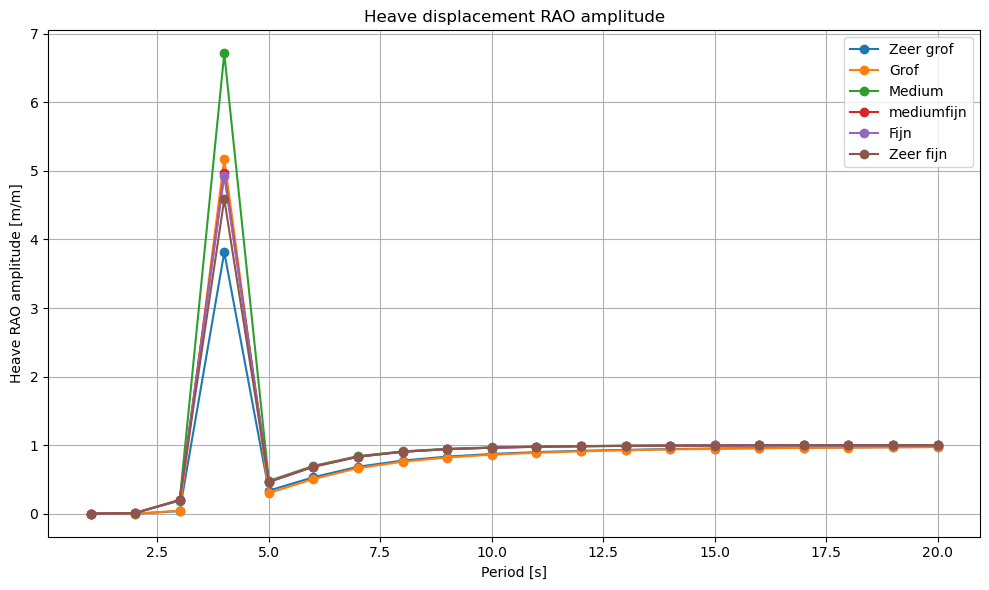

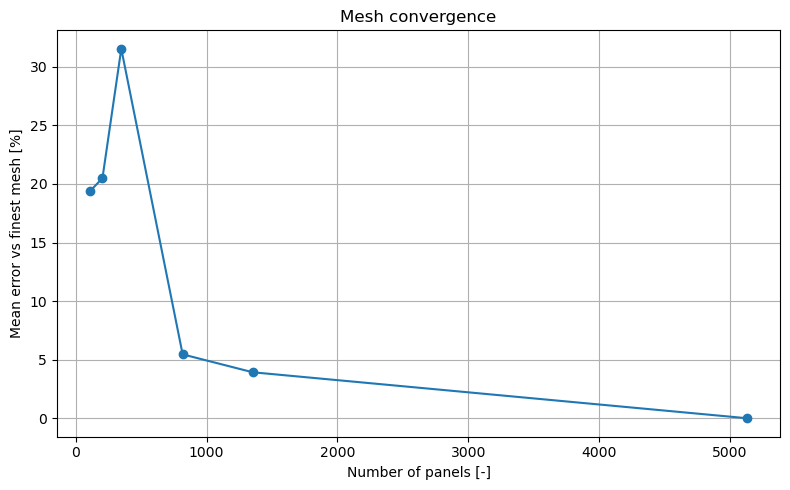


Samenvatting opgeslagen naar:
C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2\Harlequin_convergence\mesh_convergence_summary.xlsx


In [16]:

target_heading = 0
dof = "heave"
quantity = "amplitude"

sheet_name = "Displacement RAOs"

output_excel = r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2\Harlequin_convergence\mesh_convergence_summary.xlsx"

# =========================
# RAO MAP
# =========================
rao_map = {
    "surge": {
        "amplitude": {"col": 3, "label": "Surge RAO amplitude [m/m]"},
        "phase":     {"col": 4, "label": "Surge RAO phase [deg]"},
    },
    "sway": {
        "amplitude": {"col": 5, "label": "Sway RAO amplitude [m/m]"},
        "phase":     {"col": 6, "label": "Sway RAO phase [deg]"},
    },
    "heave": {
        "amplitude": {"col": 7, "label": "Heave RAO amplitude [m/m]"},
        "phase":     {"col": 8, "label": "Heave RAO phase [deg]"},
    },
    "roll": {
        "amplitude": {"col": 9,  "label": "Roll RAO amplitude [rad/m]"},
        "phase":     {"col": 10, "label": "Roll RAO phase [deg]"},
    },
    "pitch": {
        "amplitude": {"col": 11, "label": "Pitch RAO amplitude [rad/m]"},
        "phase":     {"col": 12, "label": "Pitch RAO phase [deg]"},
    },
    "yaw": {
        "amplitude": {"col": 13, "label": "Yaw RAO amplitude [rad/m]"},
        "phase":     {"col": 14, "label": "Yaw RAO phase [deg]"},
    },
}

if dof not in rao_map:
    raise ValueError(f"Onbekende dof '{dof}'. Kies uit: {list(rao_map.keys())}")

if quantity not in rao_map[dof]:
    raise ValueError("quantity moet 'amplitude' of 'phase' zijn")

target_col = rao_map[dof][quantity]["col"]
y_label = rao_map[dof][quantity]["label"]
plot_title = f"{dof.capitalize()} displacement RAO {quantity}"

# =========================
# FUNCTIES
# =========================
def read_rao_from_excel(file_path, sheet_name, target_heading, target_col):
    """
    Leest RAO-data uit een OrcaWave Excel-resultatenbestand.
    Verwacht:
    - kolom A = heading
    - kolom B = period
    - target_col = gewenste RAO-kolom
    - data start op rij 8
    """
    wb = openpyxl.load_workbook(file_path, data_only=True)
    ws = wb[sheet_name]

    periods = []
    values = []

    for r in range(8, ws.max_row + 1):
        heading = ws.cell(r, 1).value
        period = ws.cell(r, 2).value
        value = ws.cell(r, target_col).value

        if isinstance(heading, (int, float)) and isinstance(period, (int, float)):
            if abs(heading - target_heading) < 1e-9:
                periods.append(period)
                values.append(value if value is not None else np.nan)

    periods = np.array(periods, dtype=float)
    values = np.array(values, dtype=float)

    if len(periods) == 0:
        raise ValueError(f"Geen data gevonden in '{file_path}' voor heading = {target_heading}")

    idx = np.argsort(periods)
    periods = periods[idx]
    values = values[idx]

    return periods, values


def calculate_relative_error(values, ref_values):
    """
    Relatieve fout [%] t.o.v. referentie.
    Vermijdt delen door nul door NaN te gebruiken waar ref_values ~ 0.
    """
    denom = np.where(np.abs(ref_values) < 1e-12, np.nan, np.abs(ref_values))
    rel_error_percent = np.abs(values - ref_values) / denom * 100.0
    return rel_error_percent


def peak_info(periods, values):
    """
    Geeft piekwaarde en periode van piek terug.
    """
    if np.all(np.isnan(values)):
        return np.nan, np.nan

    idx_peak = np.nanargmax(values)
    return values[idx_peak], periods[idx_peak]


# =========================
# DATA INLEZEN
# =========================
all_results = []

for label, file_path, panels in meshes:
    periods, values = read_rao_from_excel(
        file_path=file_path,
        sheet_name=sheet_name,
        target_heading=target_heading,
        target_col=target_col
    )

    all_results.append({
        "label": label,
        "file": file_path,
        "panels": panels,
        "periods": periods,
        "values": values,
    })

# =========================
# REFERENTIE = FIJNSTE MESH
# =========================
reference = all_results[-1]
ref_label = reference["label"]
ref_periods = reference["periods"]
ref_values = reference["values"]
ref_peak_value, ref_peak_period = peak_info(ref_periods, ref_values)

# Controle: alle periodes moeten gelijk zijn
for result in all_results:
    same_length = len(result["periods"]) == len(ref_periods)
    same_periods = np.allclose(result["periods"], ref_periods)

    if not (same_length and same_periods):
        raise ValueError(
            f"Periodes van '{result['label']}' komen niet overeen met de referentiemesh '{ref_label}'."
        )

# =========================
# TABEL OPBOUWEN
# =========================
summary_rows = []

for result in all_results:
    label = result["label"]
    panels = result["panels"]
    periods = result["periods"]
    values = result["values"]

    rel_error_percent = calculate_relative_error(values, ref_values)
    mean_error = np.nanmean(rel_error_percent)
    max_error = np.nanmax(rel_error_percent)

    peak_value, peak_period = peak_info(periods, values)

    if abs(ref_peak_value) < 1e-12:
        peak_error_percent = np.nan
    else:
        peak_error_percent = abs(peak_value - ref_peak_value) / abs(ref_peak_value) * 100.0

    summary_rows.append({
        "Mesh": label,
        "Panels": panels,
        "Mean error vs finest mesh [%]": mean_error,
        "Max error vs finest mesh [%]": max_error,
        "Peak RAO [rad/m]": peak_value,
        "Peak period [s]": peak_period,
        "Peak error vs finest mesh [%]": peak_error_percent,
    })

summary_df = pd.DataFrame(summary_rows)

# =========================
# PRINT TABEL
# =========================
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
pd.set_option("display.precision", 3)

print("\nMesh convergence summary:\n")
print(summary_df.to_string(index=False))

# =========================
# PLOT 1: RAO CURVES
# =========================
plt.figure(figsize=(10, 6))

for result in all_results:
    plt.plot(result["periods"], result["values"], marker="o", label=result["label"])

plt.xlabel("Period [s]")
plt.ylabel(y_label)
plt.title(plot_title)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# PLOT 2: GEMIDDELDE FOUT VS PANELEN
# =========================
plot_df = summary_df.copy()

# Alleen plotten als panels zijn ingevuld (>0)
plot_df_valid = plot_df[plot_df["Panels"] > 0]

if len(plot_df_valid) > 0:
    plt.figure(figsize=(8, 5))
    plt.plot(
        plot_df_valid["Panels"],
        plot_df_valid["Mean error vs finest mesh [%]"],
        marker="o"
    )
    plt.xlabel("Number of panels [-]")
    plt.ylabel("Mean error vs finest mesh [%]")
    plt.title("Mesh convergence")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("\nLet op: panels staan nog op 0, daarom is de error-vs-panels plot niet gemaakt.")

# =========================
# OPSLAAN NAAR EXCEL
# =========================
summary_df.to_excel(output_excel, index=False)
print(f"\nSamenvatting opgeslagen naar:\n{output_excel}")